In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lakshmi25npathi_imdb_dataset_of_50k_movie_reviews_path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

print('Data source import complete.')


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


**Traitement des données textuelles**

In [5]:
# Importation du fichier CSV contenant les critiques de films IMDb
# et stockage des données dans un DataFrame pandas nommé "textes"
textes = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

# Affiche les 5 premières lignes du DataFrame
textes.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Prétraitement et Nettoyage**

In [6]:
# Installation de la bibliothèque "emoji" qui permet de gérer et manipuler des émojis en Python
!pip install emoji


In [7]:
import re
import unicodedata
import emoji

def nettoyer_texte(textes: str) -> str:
    """
    Nettoie un texte en appliquant les étapes suivantes :
    - Passage en minuscules
    - Suppression des accents
    - Suppression des balises HTML
    - Suppression des emojis
    - Suppression des chiffres
    - Suppression de certains signes de ponctuation
    - Suppression des retours à la ligne
    - Suppression des espaces multiples
    """

    # 1. Mettre en minuscules
    textes = textes.lower()

    # 5. Traduire  les emojis (as per the docstring)
    textes = emoji.demojize(textes)

    # 2. Supprimer les balises HTML
    textes = re.sub(r"<.*?>", " ", textes)

    # 3. Supprimer les retours à la ligne
    textes = textes.replace("\n", " ").replace("\r", " ")

    # 4. Supprimer les accents
    textes = unicodedata.normalize("NFD", textes)
    textes = textes.encode("ascii", "ignore").decode("utf-8")

    # 6. Supprimer les chiffres
    textes = re.sub(r"\d+", " ", textes)

    # 7. Supprimer la ponctuation (garder uniquement lettres et espaces)
    textes = re.sub(r"[^\w\s]", " ", textes)

    # 8. Supprimer les underscores (issus de \w)
    textes = textes.replace("_", " ")

    # 9. Supprimer les espaces multiples
    textes = re.sub(r"\s+", " ", textes).strip()

    return textes

In [8]:
# Application de la fonction "nettoyer_texte" à chaque critique de la colonne "review"
# Le texte nettoyé est stocké dans une nouvelle colonne appelée "review_cleaned"
textes['review_cleaned'] = textes['review'].apply(nettoyer_texte)

# Affiche les 5 premières lignes du DataFrame pour vérifier le résultat du nettoyage
print(textes.head())


                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      review_cleaned  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically there s a family where a little boy ...  
4  petter mattei s love in the time of money is a...  


In [9]:
# Importation de la bibliothèque NLTK (Natural Language Toolkit),
# utilisée pour le traitement automatique du langage naturel (TAL / NLP)
import nltk

In [10]:
# Téléchargement du paquet "punkt" de NLTK,
# utilisé pour la tokenisation, c’est-à-dire le découpage du texte en phrases ou en mots
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [11]:
# Téléchargement du module "punkt_tab" nécessaire à certaines fonctionnalités
# avancées de tokenisation avec NLTK
nltk.download('punkt_tab')

# Création d'une liste vide qui contiendra toutes les phrases extraites
sentences = []

# Parcours de chaque critique nettoyée dans la colonne "review_cleaned"
for review_text in textes['review_cleaned']:
    # Découpage de chaque critique en phrases
    # puis ajout de ces phrases à la liste "sentences"
    sentences.extend(nltk.tokenize.sent_tokenize(review_text))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [12]:
sentences

['one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldn t dare forget pretty 

In [13]:
# Application de la fonction "nettoyer_texte" à chaque phrase de la liste "sentences"
# afin de supprimer le bruit (ponctuation, caractères inutiles, etc.)
cleaned_sentences = [nettoyer_texte(s) for s in sentences]

# Affiche la liste des phrases après nettoyage
print(cleaned_sentences)

['one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldn t dare forget pretty 

In [15]:
# Affiche les 5 premières lignes du DataFrame
textes.head()

,review,sentiment,review_cleaned
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...


In [16]:
def tokenizer_nltk_simple(texte: str) -> list:
    """
    Fonction de tokenisation simple pour un texte déjà nettoyé.
    Elle découpe le texte en mots en se basant sur les espaces.
    """
    # Sépare la chaîne de caractères en une liste de mots
    # en utilisant l’espace comme séparateur
    return texte.split()


In [17]:
# Application de la fonction de tokenisation simple à chaque texte nettoyé
# de la colonne "review_cleaned"
textes['review_token'] = textes['review_cleaned'].apply(tokenizer_nltk_simple)

# Affiche les 5 premières lignes du DataFrame pour vérifier le résultat
print(textes.head())

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      review_cleaned  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically there s a family where a little boy ...   
4  petter mattei s love in the time of money is a...   

                                        review_token  
0  [one, of, the, other, reviewers, has, mentione...  
1  [a, wonderful, little, production, the, filmin...  
2  [i, thought, this, was, a, wonderful, way, to,...  
3  [basically, there, s, a, family, where, a, 

In [18]:
# Importation de la bibliothèque NLTK pour le traitement du langage naturel
import nltk

# Téléchargement de la liste de mots vides ("stopwords") en anglais
nltk.download('stopwords')

# Importation des stopwords (mots vides) et de la fonction de tokenisation en mots
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
# Création d'un ensemble ("set") de mots vides en anglais
# Ces mots seront ignorés lors de l'analyse de texte
stop_words = set(stopwords.words('english'))

In [20]:
# Application de la tokenisation en mots fournie par NLTK à chaque texte nettoyé
# La fonction word_tokenize découpe le texte en mots plus précisément qu'un simple split
textes['review_token'] = textes['review_cleaned'].apply(word_tokenize)

In [21]:
# Importation des stopwords (mots vides) depuis NLTK
from nltk.corpus import stopwords

# Téléchargement des stopwords en anglais si ce n'est pas déjà fait
nltk.download("stopwords")

# Définition d'une fonction de tokenisation qui supprime les stopwords
def tokenizer_sans_stopwords(texte: str) -> list:
    # Création d'un ensemble de mots vides en anglais
    stop_words = set(stopwords.words("english"))

    # Tokenisation du texte en mots
    tokens = word_tokenize(texte, language="english")

    # Retourne la liste des mots qui ne sont pas des stopwords
    return [t for t in tokens if t.lower() not in stop_words]



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# Application de la fonction de tokenisation qui supprime les stopwords
# à chaque texte nettoyé de la colonne "review_cleaned"
textes['review_token'] = textes['review_cleaned'].apply(tokenizer_sans_stopwords)

# Affiche les 5 premières lignes du DataFrame pour vérifier le résultat
print(textes.head())

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      review_cleaned  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically there s a family where a little boy ...   
4  petter mattei s love in the time of money is a...   

                                        review_token  
0  [one, reviewers, mentioned, watching, oz, epis...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, family, little, boy, jake, thin

In [23]:
# Importation de la bibliothèque NLTK pour le traitement du langage naturel
import nltk

# Téléchargement de différents modules nécessaires pour le NLP :
# - "punkt" : tokenisation en phrases et en mots
# - "omw-1.4" : dictionnaire multilingue pour la lemmatisation
# - "averaged_perceptron_tagger" : étiquetage grammatical (POS tagging)
# - "wordnet" : base lexicale pour la lemmatisation
nltk.download("punkt")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")

# Importation des classes pour le stemming et la lemmatisation
from nltk.stem import SnowballStemmer, WordNetLemmatizer

# Importation de la fonction de tokenisation en mots
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [24]:
# Création d'un objet SnowballStemmer pour l'anglais
# qui permet de réduire les mots à leur racine (stemming)
stemmer = SnowballStemmer(language="english")

# Création d'un objet WordNetLemmatizer
# qui permet de transformer les mots en leur forme canonique (lemmatisation)
lemmatizer = WordNetLemmatizer()


In [25]:
# Création d'une liste "words" contenant tous les mots de toutes les critiques
# La compréhension de liste parcourt chaque sous-liste de mots dans "review_token"
# et ajoute chaque mot individuellement à la liste "words"
words = [word for sublist in textes['review_token'] for word in sublist]

In [26]:
# Importation de WordNetLemmatizer pour la lemmatisation des mots
from nltk.stem import WordNetLemmatizer

# Importation de la fonction pos_tag pour l'étiquetage grammatical (Part-Of-Speech tagging)
from nltk import pos_tag

In [27]:
# Lemmatisation des mots en considérant différents types grammaticaux

# 1Lemmatisation en tant que verbe (pos='v')
# Ex. "running" → "run"
lemmatized_words = [lemmatizer.lemmatize(word, pos='v') for word in words]

# Lemmatisation en tant que nom (pos='n')
# Ex. "dogs" → "dog"
lemmatized_words = [lemmatizer.lemmatize(word, pos='n') for word in lemmatized_words]

# Lemmatisation en tant qu'adverbe (pos='r')
# Ex. "better" → "well"
lemmatized_words = [lemmatizer.lemmatize(word, pos='r') for word in lemmatized_words]


In [29]:
# Affiche la liste des mots après lemmatisation
print("Lemmatized words : ", lemmatized_words)

Lemmatized words :  ['one', 'reviewer', 'mention', 'watch', 'oz', 'episode', 'hook', 'right', 'exactly', 'happen', 'first', 'thing', 'strike', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'word', 'call', 'oz', 'nickname', 'give', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'many', 'aryan', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'scuffle', 'death', 'star', 'dodgy', 'dealing', 'shady', 'agreement', 'never', 'far', 'away', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'go', 'show', 'dare', 'forget', 'pretty', 'picture', 'paint', 'mainstream', 'audience', 'forget', 'charm', 'forget', 'romance', 'oz'

In [30]:
# Importation de WordNetLemmatizer pour la lemmatisation
from nltk.stem import WordNetLemmatizer
# Importation de pos_tag pour l'étiquetage grammatical (non utilisé ici mais souvent utile)
from nltk import pos_tag

# Définition d'une fonction de lemmatisation pour une liste de mots
def lemmatizer_nltk(words: list) -> list:
    """
    Lemmatisation des mots pour différents types grammaticaux :
    - verbes (v)
    - noms (n)
    - adverbes (r)

    Cette fonction retourne une liste de mots transformés en leurs formes de base.
    """

    # Création d'un objet WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()

    # Lemmatisation comme verbe
    lemmatized_words = [lemmatizer.lemmatize(word, pos='v') for word in words]

    # Lemmatisation comme nom
    lemmatized_words = [lemmatizer.lemmatize(word, pos='n') for word in lemmatized_words]

    # Lemmatisation comme adverbe
    lemmatized_words = [lemmatizer.lemmatize(word, pos='r') for word in lemmatized_words]

    # Retourne la liste de mots lemmatisés
    return lemmatized_words


In [32]:
# Tester ma fonction lemmatizer_nltk
words = ['one', 'reviewers', 'mentioned', 'watching','happy']

lemmatizer_nltk(words)

['one', 'reviewer', 'mention', 'watch', 'happy']

In [33]:
# Application de la fonction de lemmatisation à chaque liste de mots
# dans la colonne "review_token"
textes['review_lemma'] = textes['review_token'].apply(lemmatizer_nltk)

# Affiche les 5 premières lignes du DataFrame pour vérifier le résultat
print(textes.head())

                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      review_cleaned  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically there s a family where a little boy ...   
4  petter mattei s love in the time of money is a...   

                                        review_token  \
0  [one, reviewers, mentioned, watching, oz, epis...   
1  [wonderful, little, production, filming, techn...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, family, little, boy, jake, 

In [34]:
# Importation de la bibliothèque pandas (si ce n'est pas déjà fait)
import pandas as pd

# Sauvegarde du DataFrame "textes" dans un fichier CSV nommé "imdb_clean.csv"
# Cela permet de conserver les critiques nettoyées, tokenisées et lemmatisées
textes.to_csv('imdb_clean.csv', index=False)

In [35]:
textes_clean = pd.read_csv('imdb_clean.csv')
textes_clean.head()

,review,sentiment,review_cleaned,review_token,review_lemma
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"['one', 'reviewers', 'mentioned', 'watching', ...","['one', 'reviewer', 'mention', 'watch', 'oz', ..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"['wonderful', 'little', 'production', 'filming...","['wonderful', 'little', 'production', 'film', ..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"['thought', 'wonderful', 'way', 'spend', 'time...","['think', 'wonderful', 'way', 'spend', 'time',..."
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"['basically', 'family', 'little', 'boy', 'jake...","['basically', 'family', 'little', 'boy', 'jake..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...,"['petter', 'mattei', 'love', 'time', 'money', ...","['petter', 'mattei', 'love', 'time', 'money', ..."


**Analyse des données textuelles**

**Sentiment le plus prévalent**



In [36]:
# Importation de la bibliothèque WordCloud pour générer des nuages de mots
from wordcloud import WordCloud, STOPWORDS

# Importation de matplotlib pour afficher les graphiques
import matplotlib.pyplot as plt


In [37]:
# le sentiment le plus prévalent
# Comptage du nombre de critiques pour chaque sentiment (positif ou négatif)
sentiment_counts = textes_clean['sentiment'].value_counts()

# Affiche le nombre de critiques pour chaque sentiment
print(sentiment_counts)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**- Le nombre myen de mots par commentaire**

In [38]:
# Le nombre moyen de mots par commentaire

# Création d'une nouvelle colonne "nb_mots" contenant le nombre de mots
# dans chaque critique tokenisée
textes_clean['nb_mots'] = textes_clean['review_token'].apply(len)

# Calcul du nombre moyen de mots par critique
nb_mots_moyen = textes_clean['nb_mots'].mean()

# Affiche le nombre moyen de mots
print(nb_mots_moyen)


1169.1516


**- Les mots les plus fréquents**

In [60]:
# Les mots les plus fréquents
from collections import Counter

# Aplatir toutes les listes de tokens
tous_les_mots = [mot for tokens in textes['review_token'] for mot in tokens]

# Compter les fréquences
frequences = Counter(tous_les_mots)

# Top 20 mots les plus fréquents
frequences.most_common()


[('movie', 87964),
 ('film', 79692),
 ('one', 53595),
 ('like', 40166),
 ('good', 29753),
 ('time', 25103),
 ('even', 24866),
 ('would', 24602),
 ('story', 23119),
 ('really', 23094),
 ('see', 23026),
 ('well', 21256),
 ('much', 19316),
 ('bad', 18471),
 ('get', 18420),
 ('people', 18183),
 ('great', 18145),
 ('also', 17977),
 ('first', 17579),
 ('made', 16152),
 ('make', 15898),
 ('way', 15643),
 ('could', 15565),
 ('movies', 15304),
 ('characters', 14456),
 ('think', 14338),
 ('watch', 13944),
 ('character', 13902),
 ('films', 13761),
 ('two', 13544),
 ('many', 13446),
 ('seen', 13374),
 ('love', 13009),
 ('plot', 12985),
 ('never', 12981),
 ('life', 12915),
 ('acting', 12867),
 ('show', 12656),
 ('best', 12610),
 ('know', 12510),
 ('little', 12433),
 ('ever', 12028),
 ('man', 11818),
 ('better', 11429),
 ('end', 11119),
 ('scene', 10970),
 ('still', 10857),
 ('say', 10770),
 ('scenes', 10479),
 ('something', 10145),
 ('go', 9965),
 ('back', 9675),
 ('real', 9432),
 ('thing', 9177),


**Visualiser les words cloud pour les avis positifs**

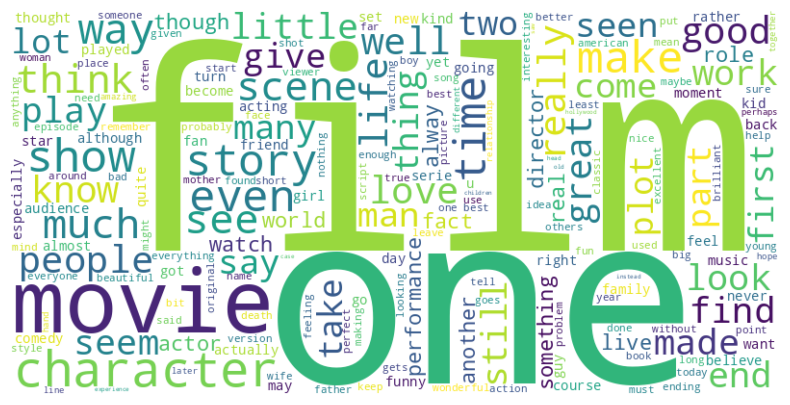

In [56]:
# Visualiser les words cloud pour les avis positifs
avis_positifs = textes[textes['sentiment'] == 'positive']
tous_les_mots_positifs = [mot for tokens in avis_positifs['review_token'] for mot in tokens]
wordcloud_positifs = WordCloud(width=800, height=400, background_color='white').generate(' '.join(tous_les_mots_positifs))
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_positifs, interpolation='bilinear')
plt.axis('off')
plt.show()

**Analyses et Interprétations :**

Ce second nuage de mots confirme et précise les tendances observées précédemment. Les termes « film » et « one » dominent, suggérant des comparaisons fréquentes entre œuvres ou des jugements centrés sur des films spécifiques. Les mots « story », « scene », « character » et « performance » renforcent l’importance de la narration, des personnages et du jeu d’acteur. La forte présence de verbes cognitifs et perceptifs (« think », « know », « see », « feel ») indique un discours très subjectif, axé sur l’expérience personnelle du spectateur. Les adjectifs évaluatifs (« good », « great », « nice », « bad ») traduisent une logique d’appréciation. L’ensemble révèle un corpus de critiques détaillées, où analyse narrative et jugement émotionnel sont étroitement liés.

**Visualiser les words cloud pour les avis negatifs**

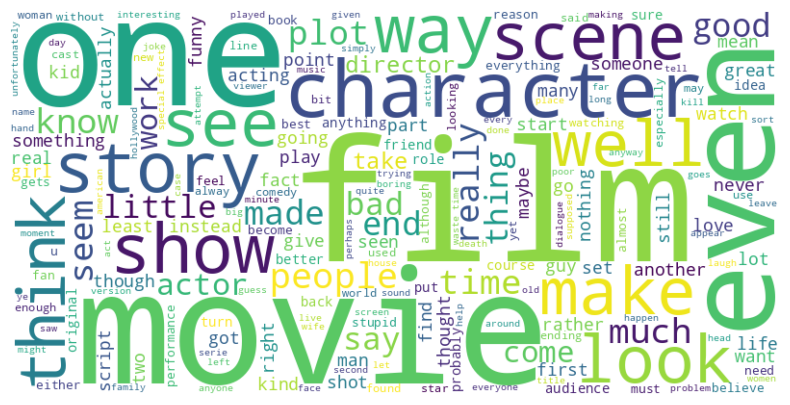

In [57]:
# Visualiser les words cloud pour les avis negatifs
avis_negatifs = textes[textes['sentiment'] == 'negative']
tous_les_mots_negatifs = [mot for tokens in avis_negatifs['review_token'] for mot in tokens]
wordcloud_negatifs = WordCloud(width=800, height=400, background_color='white').generate(' '.join(tous_les_mots_negatifs))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negatifs, interpolation='bilinear')
plt.axis('off')
plt.show()

**Analyses et Interprétations :**

analyses et interprétation en 800 caractères

Le nuage de mots met en évidence les termes les plus fréquents d’un corpus centré sur le cinéma et les séries. Les mots dominants comme « movie », « film », « character », « story » et « scene » confirment un fort accent sur la narration, les personnages et la mise en scène. La présence marquée de verbes subjectifs (« see », « say », « make », « look », « think ») et d’adjectifs évaluatifs (« good », « bad », « funny », « interesting ») révèle un discours d’opinion, typique de critiques ou avis de spectateurs. Les mots « show », « actor », « director » soulignent l’attention portée aux performances et à la réalisation. Globalement, ce nuage reflète une analyse subjective et descriptive des œuvres, où l’expérience du spectateur et la qualité perçue occupent une place centrale.

**Bar plots des mots les plus communs**

<BarContainer object of 20 artists>

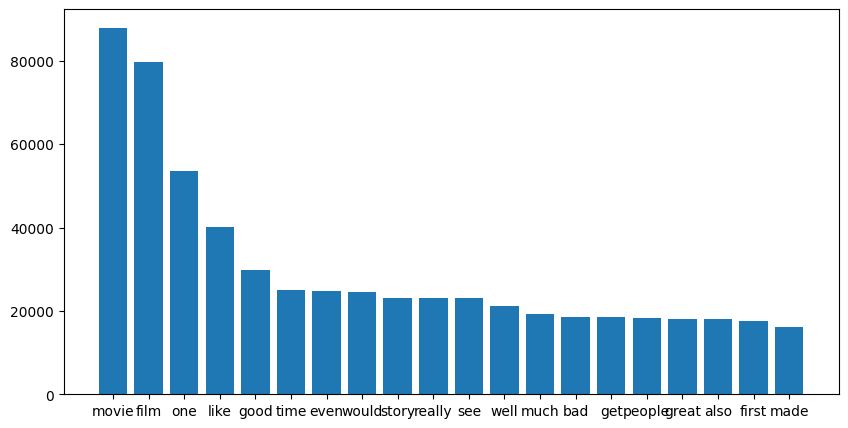

In [61]:
# Bar plots des mots les plus communs
nb_mots_par_mot = Counter(tous_les_mots)
mots_communs = nb_mots_par_mot.most_common(20)
mots, frequences = zip(*mots_communs)

plt.figure(figsize=(10, 5))
plt.bar(mots, frequences)

**Analyses et Interprétations :**

Le graphique présente la fréquence des mots les plus utilisés dans un corpus lié au cinéma. Les termes « movie » et « film » dominent largement, indiquant un sujet central clairement orienté vers les œuvres cinématographiques. La forte présence de mots comme « like », « good », « great » et « bad » suggère un contenu évaluatif, probablement des critiques ou avis de spectateurs. Les mots « time », « story », « people » et « made » renvoient à l’expérience du visionnage, à la narration et à la production. L’ensemble révèle un discours majoritairement descriptif et subjectif, typique de commentaires ou critiques de films, où l’opinion personnelle et la qualité perçue occupent une place centrale.

**Histogrammes de la grandeur des commentaires**

Text(0, 0.5, 'Fréquence')

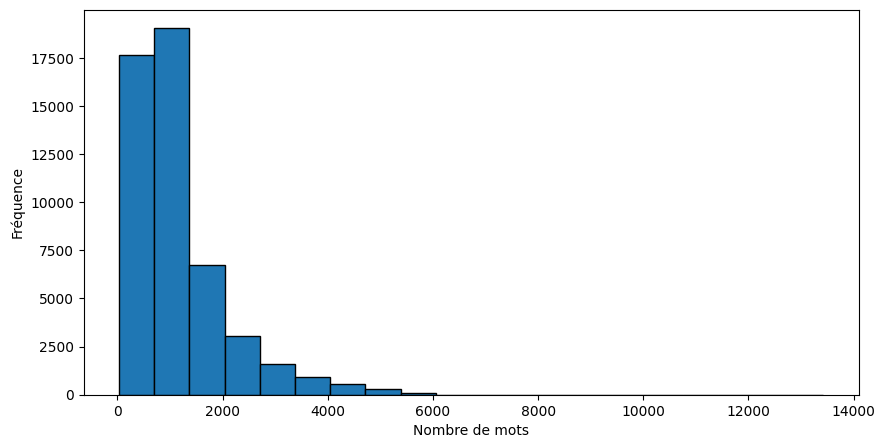

In [62]:
# Histogrammes de la grandeur des commentaires
plt.figure(figsize=(10, 5))
plt.hist(textes_clean['nb_mots'], bins=20, edgecolor='black')
plt.xlabel('Nombre de mots')
plt.ylabel('Fréquence')

**Analyses et Interprétations :**

L’histogramme montre la distribution du nombre de mots par document. La majorité des textes se concentre dans les classes basses, principalement entre 0 et 2000 mots, ce qui indique que le corpus est composé surtout de documents courts à moyens. La distribution est fortement asymétrique à droite : quelques textes très longs atteignent plusieurs milliers de mots, mais ils restent rares. Cette longue traîne suggère une hétérogénéité du corpus, avec un petit nombre de documents détaillés ou exhaustifs. Globalement, le corpus est dominé par des contenus concis, typiques de critiques, avis ou commentaires, tandis que les textes longs peuvent correspondre à analyses approfondies ou articles spécialisés.

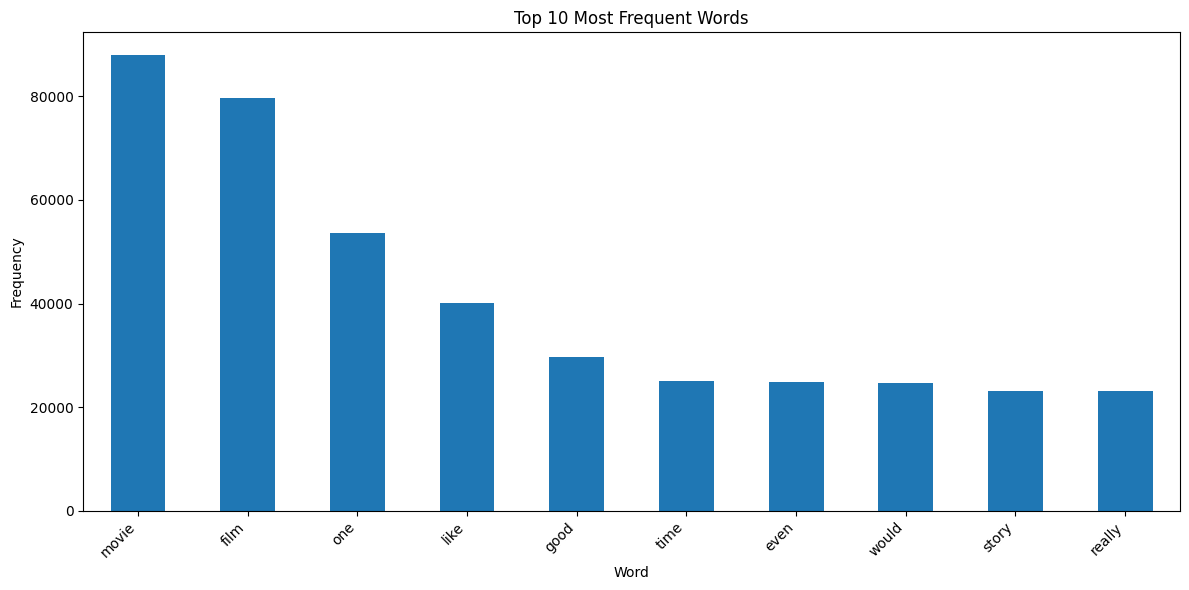

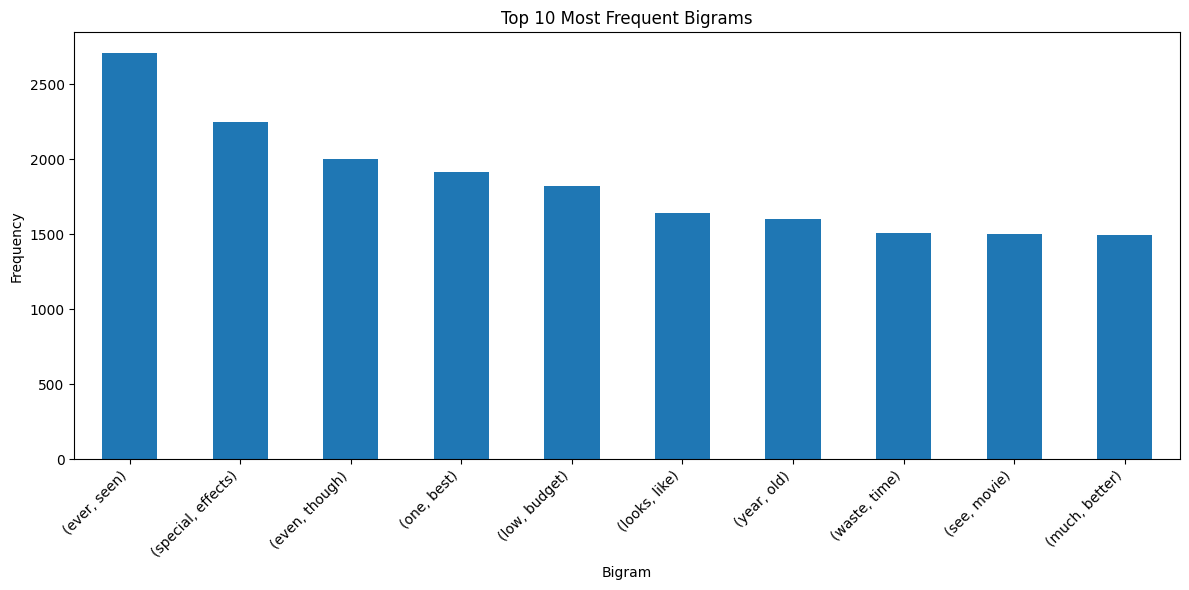

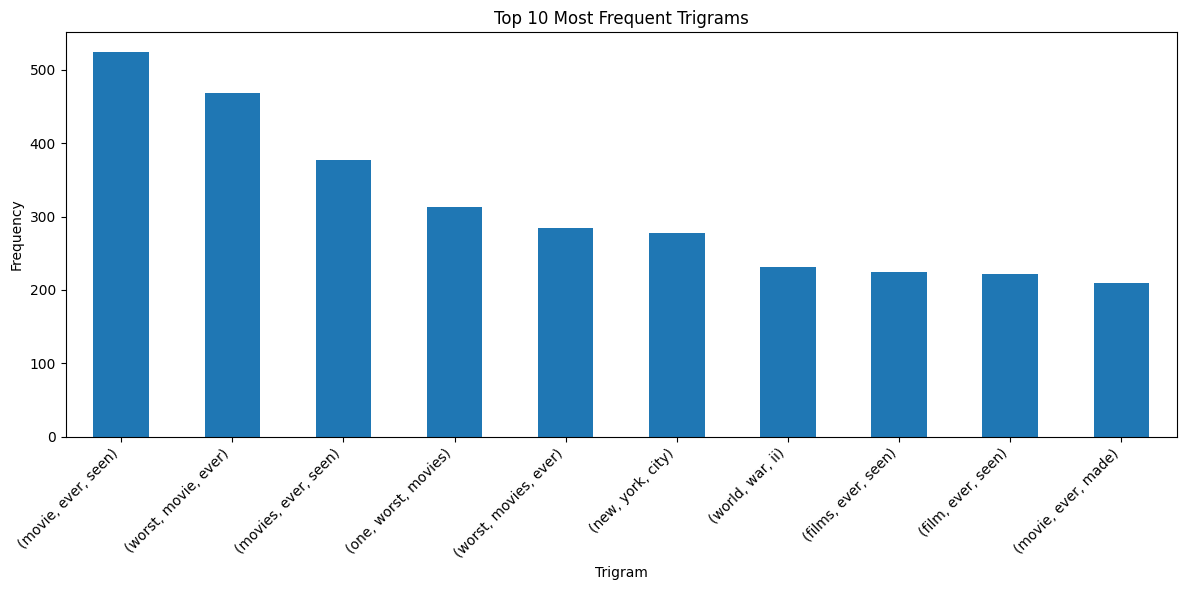

In [63]:
import matplotlib.pyplot as plt
from nltk import FreqDist
from nltk.util import ngrams

# Calculate word frequencies (unigrams)
tous_les_mots = [word for sublist in textes['review_token'] for word in sublist]
word_counts = FreqDist(tous_les_mots)
sorted_word_counts = pd.Series(word_counts).sort_values(ascending=False)

# Calculate bigram frequencies
all_bigrams = [b for s in textes['review_token'] for b in ngrams(s, 2)]
bigram_counts = FreqDist(all_bigrams)
sorted_bigram_counts = pd.Series(bigram_counts).sort_values(ascending=False)

# Calculate trigram frequencies
all_trigrams = [t for s in textes['review_token'] for t in ngrams(s, 3)]
trigram_counts = FreqDist(all_trigrams)
sorted_trigram_counts = pd.Series(trigram_counts).sort_values(ascending=False)

# Plot top 10 most frequent words
plt.figure(figsize=(12, 6))
sorted_word_counts.head(10).plot(kind='bar')
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot top 10 most frequent bigrams
plt.figure(figsize=(12, 6))
sorted_bigram_counts.head(10).plot(kind='bar')
plt.title("Top 10 Most Frequent Bigrams")
plt.xlabel("Bigram")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot top 10 most frequent trigrams
plt.figure(figsize=(12, 6))
sorted_trigram_counts.head(10).plot(kind='bar')
plt.title("Top 10 Most Frequent Trigrams")
plt.xlabel("Trigram")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analyses et Interprétations :**

Le graphique des mots les plus fréquents montre une forte dominance de termes génériques et contextuels comme movie, film, one ou like. Cela indique que le corpus est centré sur des critiques de films et que le vocabulaire principal décrit davantage le sujet que l’émotion. Le mot good est le seul clairement chargé positivement dans le top 10, ce qui peut expliquer le biais des méthodes lexicon-based vers le sentiment positif. Les termes time, story, really ou would sont neutres et dépendent fortement du contexte, ce qui complique l’analyse de sentiment automatique. Ces résultats suggèrent que la fréquence brute des mots est peu discriminante pour le sentiment et qu’une prise en compte du contexte, des n-grams ou de modèles supervisés serait plus adaptée.

Bigram

L’analyse des bigrammes les plus fréquents révèle des expressions plus informatives que les mots isolés. Certains bigrammes sont clairement évaluatifs, comme much better ou one best, traduisant un sentiment positif marqué, tandis que waste time ou low budget véhiculent une connotation négative. D’autres, tels que special effects ou year old, sont plutôt descriptifs et dépendent du contexte. La présence de ever seen suggère des formulations emphatiques souvent associées à des jugements forts, positifs ou négatifs. Comparée aux unigrammes, cette analyse montre que les bigrammes capturent mieux la polarité et l’intention, ce qui explique pourquoi les modèles intégrant des n-grams ou le contexte obtiennent généralement de meilleures performances en analyse de sentiment.

Trigram

Les trigrammes les plus fréquents mettent en évidence des structures linguistiques fortement évaluatives. Des expressions comme movie ever seen, films ever seen ou film ever seen traduisent une emphase extrême, souvent associée à des jugements très positifs ou très négatifs. La présence répétée de worst movies ever et one worst movies indique une forte charge négative explicite, facilement exploitable par les modèles de sentiment. D’autres trigrammes comme new york city ou world war ii sont purement contextuels et illustrent le cadre narratif des critiques. Globalement, ces résultats montrent que les trigrammes capturent le contexte et l’intensité émotionnelle bien mieux que les unigrammes et bigrammes, renforçant l’intérêt des modèles sensibles au contexte pour l’analyse de sentiment.

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = ["This is the first document.","This document is the second document."]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print(vectorizer.get_feature_names_out())
print(X.toarray())


['document' 'first' 'is' 'second' 'the' 'this']
[[0.4090901  0.57496187 0.4090901  0.         0.4090901  0.4090901 ]
 [0.66758217 0.         0.33379109 0.46913173 0.33379109 0.33379109]]


In [65]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.0 MB/s eta 0:00:00


In [66]:
from gensim.models import Word2Vec
sentences = [["This", "is", "the", "first", "sentence"], ["This", "is", "the", "second", "sentence"]]
model = Word2Vec(sentences, min_count=1)
print(model.wv["sentence"])
print(model.wv.most_similar("sentence"))

[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.4986202e-03 -4.4621765e-03
  4.5175003e-03 -6.7869602e-03 -3.5484887e-03  9.3985079e-03
 -1.5776526e-03  3.2137157e-04 -4.1406299e-03 -7.6826881e-03
 -1.5080082e-03  2.46979

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

# corpus = ["This is the first document.","This document is the second document."]
# Join the list of tokens back into a single string for each review
# corpus = textes['review_lemma'].apply(lambda x: ' '.join(x))
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(textes_clean['review_lemma'])
print(vectorizer.get_feature_names_out())
print(X.toarray())

['ability' 'able' 'absolutely' 'accent' 'accept' 'across' 'act' 'action'
 'actor' 'actress' 'actual' 'actually' 'adaptation' 'add' 'admit' 'adult'
 'adventure' 'age' 'ago' 'agree' 'air' 'alien' 'alive' 'allow' 'almost'
 'alone' 'along' 'already' 'also' 'although' 'always' 'amaze' 'america'
 'american' 'among' 'amount' 'amuse' 'animal' 'animation' 'annoy'
 'another' 'answer' 'anti' 'anyone' 'anything' 'anyway' 'apart'
 'apparently' 'appeal' 'appear' 'appearance' 'appreciate' 'approach'
 'around' 'art' 'aside' 'ask' 'aspect' 'atmosphere' 'attack' 'attempt'
 'attention' 'audience' 'average' 'avoid' 'award' 'away' 'awful' 'baby'
 'back' 'background' 'bad' 'badly' 'band' 'bar' 'base' 'basic' 'basically'
 'battle' 'bear' 'beat' 'beautiful' 'beauty' 'become' 'begin' 'behind'
 'believable' 'believe' 'ben' 'best' 'beyond' 'big' 'biggest' 'bill'
 'bite' 'bizarre' 'black' 'blood' 'blow' 'blue' 'body' 'bond' 'book'
 'bore' 'bother' 'box' 'boy' 'brain' 'break' 'brilliant' 'bring' 'british'
 'brothe

**Analyse du sentiment supervisés : SVM et Random Forest**

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
# diviser les donnees en train et en test
x_train, x_test, y_train, y_test = train_test_split(X, textes_clean['sentiment'], test_size=0.2, random_state=42)
# On initialise un modèle LinearSVC
svm_model = LinearSVC()
# On entraine le modèle sur les données d'entraînement
svm_model.fit(x_train, y_train)
# On évalue le modèle sur les données de test
print("SVM model trained successfully")
accuracy = svm_model.score(x_test, y_test)
print("Accuracy:", accuracy)

SVM model trained successfully
Accuracy: 0.8645


**Essayons pour le model Random Forest**

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Division des données en train et test
x_train, x_test, y_train, y_test = train_test_split(
    X,
    textes_clean['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=textes_clean['sentiment']  # recommandé pour la classification
)

# Initialisation du modèle Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Entraînement du modèle
rf_model.fit(x_train, y_train)

print("Random Forest model trained successfully")

# Évaluation du modèle
accuracy = rf_model.score(x_test, y_test)
print("Accuracy:", accuracy)



Random Forest model trained successfully
Accuracy: 0.8403


**Analyse du sentiment non supervisés : TextBblob et Vader**

In [83]:
# Installation de la bibliothèque "vaderSentiment" pour l'analyse de sentiments
# VADER (Valence Aware Dictionary and sEntiment Reasoner) est spécialisée pour les textes courts, comme les critiques
!pip install vaderSentiment

In [74]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# Appliquer l'analyse de sentiment TextBlob
textes_clean['sentiment_textblob'] = textes_clean['review_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Appliquer l'analyse de sentiment Vader
analyzer = SentimentIntensityAnalyzer()
textes_clean['sentiment_vader'] = textes_clean['review_cleaned'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
# Verifier les resultats
print("Dataframe apres l'analyse de sentiment")
display(textes_clean[["review","review_cleaned","sentiment","sentiment_textblob","sentiment_vader"]].head())

Dataframe apres l'analyse de sentiment


,review,review_cleaned,sentiment,sentiment_textblob,sentiment_vader
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive,0.052316,-0.9917
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive,0.108308,0.9657
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive,0.356198,0.9812
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative,0.001389,-0.8858
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive,0.214483,0.9766


In [75]:
# Définition d'une fonction qui attribue un label de sentiment à un score
def assign_sentiment_label(score):
    """
    Transforme un score numérique en label de sentiment :
    - si le score est supérieur à 0 → 'positive'
    - sinon → 'negative'
    """
    if score > 0:
        return 'positive'
    else:
        return 'negative'


In [76]:
# Application de la fonction "assign_sentiment_label" à la colonne "sentiment_vader"
# pour créer une nouvelle colonne "vader_label" contenant le label de sentiment correspondant
textes_clean['vader_label'] = textes_clean['sentiment_vader'].apply(assign_sentiment_label)

# Application de la même fonction à la colonne "sentiment_textblob"
# pour créer une nouvelle colonne "textblob_label"
textes_clean['textblob_label'] = textes_clean['sentiment_textblob'].apply(assign_sentiment_label)

# Affiche les 5 premières lignes du DataFrame pour vérifier les modifications
textes_clean.head()

,review,sentiment,review_cleaned,review_token,review_lemma,nb_mots,sentiment_textblob,sentiment_vader,vader_label,textblob_label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"['one', 'reviewers', 'mentioned', 'watching', ...","['one', 'reviewer', 'mention', 'watch', 'oz', ...",1590,0.052316,-0.9917,negative,positive
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"['wonderful', 'little', 'production', 'filming...","['wonderful', 'little', 'production', 'film', ...",915,0.108308,0.9657,positive,positive
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"['thought', 'wonderful', 'way', 'spend', 'time...","['think', 'wonderful', 'way', 'spend', 'time',...",825,0.356198,0.9812,positive,positive
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"['basically', 'family', 'little', 'boy', 'jake...","['basically', 'family', 'little', 'boy', 'jake...",626,0.001389,-0.8858,negative,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...,"['petter', 'mattei', 'love', 'time', 'money', ...","['petter', 'mattei', 'love', 'time', 'money', ...",1228,0.214483,0.9766,positive,positive


**Comparer sentiment,	vader_label	,textblob_label en créean la matrice confusion**

In [84]:
# Importation des fonctions pour calculer et afficher une matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Importation de matplotlib pour l'affichage graphique
import matplotlib.pyplot as plt


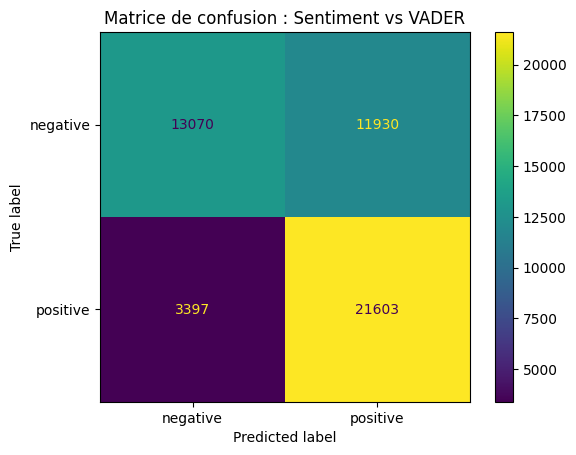

In [79]:
# Calcul de la matrice de confusion entre les sentiments réels et les prédictions VADER
cm_vader = confusion_matrix(
    textes_clean['sentiment'],     # véritables labels
    textes_clean['vader_label']    # labels prédits par VADER
)

# Création d'un objet pour afficher la matrice de confusion
disp_vader = ConfusionMatrixDisplay(
    confusion_matrix=cm_vader,
    display_labels=sorted(textes_clean['sentiment'].unique())  # labels uniques triés
)

# Affichage de la matrice de confusion
disp_vader.plot()
plt.title("Matrice de confusion : Sentiment vs VADER")
plt.show()

**Analyses et Interprétations :**

Cette matrice de confusion compare les sentiments réels des critiques de films (« True label ») avec les prédictions de l’outil VADER (« Predicted label »).

En haut à gauche (13070), on a les vrais négatifs correctement prédits comme négatifs.

En bas à droite (21603), on a les vrais positifs correctement prédits comme positifs.

Ces deux chiffres représentent les bonnes classifications.

En haut à droite (11930), ce sont des critiques négatives mal classées comme positives (faux positifs).

En bas à gauche (3397), ce sont des critiques positives mal classées comme négatives (faux négatifs).

Interprétation : VADER détecte bien les avis positifs, avec un taux d’erreur plus faible (3397 faux négatifs) que pour les avis négatifs (11930 faux positifs).

Cela montre une certaine tendance à surclasser les critiques négatives en positives, ce qui peut biaiser l’analyse.

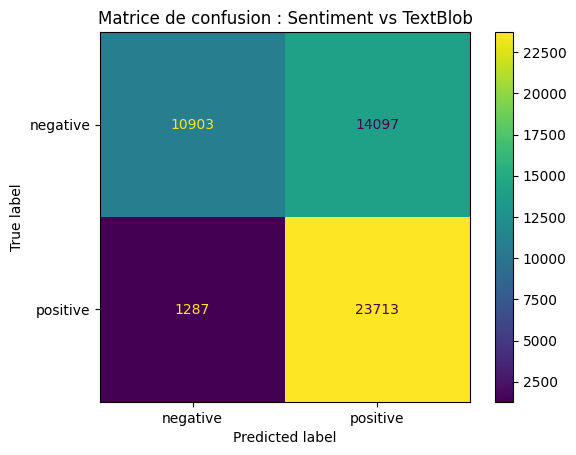

In [80]:
# Calcul de la matrice de confusion entre les sentiments réels et les prédictions TextBlob
cm_textblob = confusion_matrix(
    textes_clean['sentiment'],       # véritables labels
    textes_clean['textblob_label']   # labels prédits par TextBlob
)

# Création d'un objet pour afficher la matrice de confusion
disp_textblob = ConfusionMatrixDisplay(
    confusion_matrix=cm_textblob,
    display_labels=sorted(textes_clean['sentiment'].unique())  # labels uniques triés
)

# Affichage de la matrice de confusion
disp_textblob.plot()
plt.title("Matrice de confusion : Sentiment vs TextBlob")
plt.show()


**Analyses et Interprétations :**

Cette matrice de confusion compare les sentiments réels avec les prédictions de TextBlob.

En haut à gauche (10903) : vrais négatifs correctement identifiés.

En bas à droite (23713) : vrais positifs correctement identifiés.

Ces deux valeurs montrent les bonnes classifications.

En haut à droite (14097) : critiques négatives classées à tort comme positives (faux positifs).

En bas à gauche (1287) : critiques positives mal classées comme négatives (faux négatifs).

Interprétation : TextBlob est plus précis pour détecter les avis positifs avec un faible nombre de faux négatifs (1287). En revanche, il commet plus d’erreurs sur les avis négatifs, avec 14097 faux positifs, soit un taux d’erreur plus élevé que pour VADER sur ce point.

TextBlob semble donc avoir une tendance à surclasser les avis négatifs en positifs, mais fait globalement moins d’erreurs sur les avis positifs que VADER.

Cela suggère que TextBlob est légèrement plus performant que VADER dans cette tâche, notamment pour identifier correctement les avis positifs.

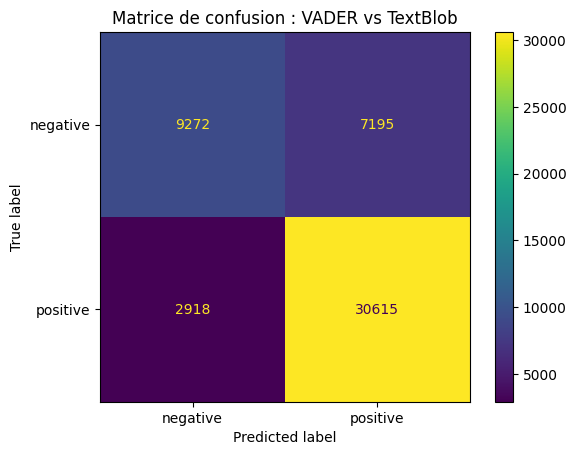

In [81]:
# Calcul de la matrice de confusion entre les prédictions VADER et TextBlob
cm_vader_textblob = confusion_matrix(
    textes_clean['vader_label'],       # labels prédits par VADER
    textes_clean['textblob_label']     # labels prédits par TextBlob
)

# Création d'un objet pour afficher la matrice de confusion
disp_vt = ConfusionMatrixDisplay(
    confusion_matrix=cm_vader_textblob,
    display_labels=sorted(textes_clean['vader_label'].unique())  # labels uniques triés
)

# Affichage de la matrice de confusion
disp_vt.plot()
plt.title("Matrice de confusion : VADER vs TextBlob")
plt.show()


**Analyses et Interprétations :**

Cette matrice de confusion compare directement les prédictions de VADER (« True label ») avec celles de TextBlob (« Predicted label »).

En haut à gauche (9272), VADER et TextBlob s’accordent pour classer certaines critiques comme négatives.

En bas à droite (30615), ils s’accordent sur les critiques positives.

Ces valeurs représentent les accords entre les deux outils.

En haut à droite (7195), VADER a prédit négatif alors que TextBlob a prédit positif.

En bas à gauche (2918), VADER a prédit positif alors que TextBlob a prédit négatif.

Cela montre une bonne concordance globale, notamment sur les avis positifs, avec plus de 30 000 accords. Cependant, des différences subsistent, surtout sur les critiques négatives, où les désaccords sont plus fréquents.

En résumé, VADER et TextBlob ont tendance à s’aligner sur la plupart des sentiments positifs, mais TextBlob semble plus enclin à classer certains avis négatifs en positifs, expliquant les désaccords observés.

In [82]:
# Importation de la fonction pour générer un rapport de classification
from sklearn.metrics import classification_report

# Rapport de classification pour comparer les prédictions VADER aux sentiments réels
print("VADER vs Sentiment")
print(classification_report(
    textes_clean['sentiment'],     # véritables labels
    textes_clean['vader_label']    # labels prédits par VADER
))

# Rapport de classification pour comparer les prédictions TextBlob aux sentiments réels
print("TextBlob vs Sentiment")
print(classification_report(
    textes_clean['sentiment'],         # véritables labels
    textes_clean['textblob_label']     # labels prédits par TextBlob
))


VADER vs Sentiment
              precision    recall  f1-score   support

    negative       0.79      0.52      0.63     25000
    positive       0.64      0.86      0.74     25000

    accuracy                           0.69     50000
   macro avg       0.72      0.69      0.68     50000
weighted avg       0.72      0.69      0.68     50000

TextBlob vs Sentiment
              precision    recall  f1-score   support

    negative       0.89      0.44      0.59     25000
    positive       0.63      0.95      0.76     25000

    accuracy                           0.69     50000
   macro avg       0.76      0.69      0.67     50000
weighted avg       0.76      0.69      0.67     50000



**Analyses et Interprétations : **

Les résultats montrent que VADER et TextBlob atteignent une accuracy identique de 0,69, indiquant des performances globales comparables. Toutefois, leurs comportements diffèrent selon la polarité.
VADER présente un meilleur équilibre : il identifie mieux les avis négatifs (rappel 0,52) que TextBlob (0,44), mais au prix d’un rappel plus faible pour le positif. Son F1-score négatif (0,63) est supérieur à celui de TextBlob (0,59), ce qui suggère une meilleure détection des critiques.
TextBlob, en revanche, est fortement biaisé vers le positif : il capte très bien les avis positifs (rappel 0,95) mais manque beaucoup de négatifs, malgré une précision élevée (0,89).
En résumé, VADER est plus équilibré, tandis que TextBlob favorise la détection du sentiment positif, ce qui peut être problématique dans des contextes où les avis négatifs sont critiques.

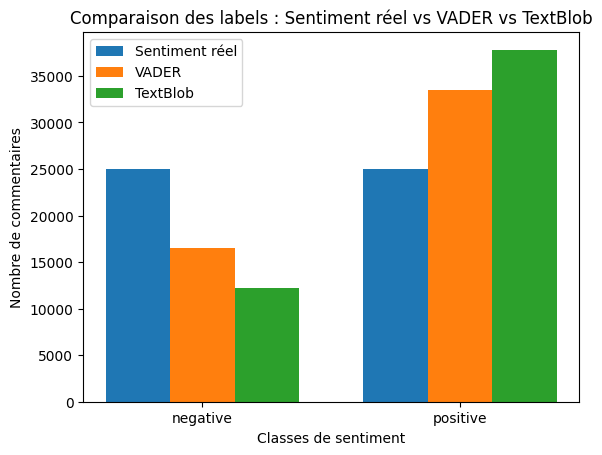

In [62]:
import matplotlib.pyplot as plt

# Comptage des classes
sentiment_counts = textes_clean['sentiment'].value_counts().sort_index()
vader_counts = textes_clean['vader_label'].value_counts().sort_index()
textblob_counts = textes_clean['textblob_label'].value_counts().sort_index()

# Harmonisation des labels
labels = sorted(set(sentiment_counts.index)
                | set(vader_counts.index)
                | set(textblob_counts.index))

sentiment_counts = sentiment_counts.reindex(labels, fill_value=0)
vader_counts = vader_counts.reindex(labels, fill_value=0)
textblob_counts = textblob_counts.reindex(labels, fill_value=0)

# Paramètres du graphique
x = range(len(labels))
width = 0.25

plt.figure()
plt.bar(x, sentiment_counts, width=width)
plt.bar([i + width for i in x], vader_counts, width=width)
plt.bar([i + 2 * width for i in x], textblob_counts, width=width)

plt.xticks([i + width for i in x], labels)
plt.xlabel("Classes de sentiment")
plt.ylabel("Nombre de commentaires")
plt.title("Comparaison des labels : Sentiment réel vs VADER vs TextBlob")
plt.legend(["Sentiment réel", "VADER", "TextBlob"])

plt.show()


**Analyses et Interprétations :**

Le graphique compare la répartition des labels de sentiment réels, prédits par VADER et prédits par TextBlob. Les données réelles sont parfaitement équilibrées, avec 25 000 avis négatifs et 25 000 positifs. En revanche, les deux méthodes automatiques montrent un déséquilibre marqué en faveur du sentiment positif.

VADER prédit environ 33 500 avis positifs contre 16 500 négatifs. Cela indique une tendance à surclasser les avis positifs, bien qu’il conserve une capacité modérée à identifier les négatifs. Ce biais explique son rappel plus élevé pour le positif et plus faible pour le négatif observé précédemment.

TextBlob accentue encore davantage ce phénomène : près de 38 000 avis sont classés positifs contre seulement 12 000 négatifs. Cette forte asymétrie confirme que TextBlob est très optimiste, privilégiant largement le sentiment positif. Cela se traduit par un excellent rappel pour le positif, mais une incapacité notable à détecter correctement les avis négatifs.

En interprétation globale, ces résultats suggèrent que les lexiques utilisés favorisent les expressions positives, souvent plus explicites, tandis que le négatif est plus nuancé ou implicite. Pour des applications sensibles aux critiques (service client, détection d’insatisfaction), VADER reste plus fiable que TextBlob, mais des modèles supervisés ou un rééquilibrage seraient préférables.